# Curating COVID example data


Canadian HV.1 and JN.1 data was downloaded on 2026-02-24 from [ViruSeq Portal](https://virusseq-dataportal.ca/explorer?filters=%7B%22content%22%3A%5B%7B%22content%22%3A%7B%22fieldName%22%3A%22analysis.first_published_at%22%2C%22value%22%3A1735707600000%7D%2C%22op%22%3A%22%3E%3D%22%7D%2C%7B%22content%22%3A%7B%22fieldName%22%3A%22analysis.first_published_at%22%2C%22value%22%3A1749873599999%7D%2C%22op%22%3A%22%3C%3D%22%7D%2C%7B%22content%22%3A%7B%22fieldName%22%3A%22analysis.lineage_analysis.lineage_name%22%2C%22value%22%3A%5B%22LP.8.1%22%2C%22LP.8.1.1%22%2C%22LP.8.1.10%22%2C%22LP.8.1.11%22%2C%22LP.8.1.13%22%2C%22LP.8.1.2%22%2C%22LP.8.1.3%22%2C%22LP.8.1.4%22%2C%22LP.8.1.5%22%2C%22LP.8.1.7%22%2C%22LP.8.1.8%22%2C%22NB.1.8.1%22%2C%22NW.1%22%2C%22NW.1.2.2%22%2C%22NW.1.5%22%2C%22NW.1.7%22%2C%22NW.3%22%2C%22NY.1%22%2C%22NY.1.1%22%2C%22NY.1.2%22%2C%22NY.10%22%2C%22NY.11.1%22%2C%22NY.12%22%2C%22NY.13%22%2C%22NY.13.1%22%2C%22NY.13.3%22%2C%22NY.15%22%2C%22NY.15.1%22%2C%22NY.16%22%2C%22NY.17%22%2C%22NY.18%22%2C%22NY.18.1%22%2C%22NY.19%22%2C%22NY.2%22%2C%22NY.21%22%2C%22NY.22%22%2C%22NY.23%22%2C%22NY.24%22%2C%22NY.26.1%22%2C%22NY.3%22%2C%22NY.3.3%22%2C%22NY.3.4%22%2C%22NY.4.1%22%2C%22NY.5%22%2C%22NY.6%22%2C%22NY.7%22%2C%22NY.7.1%22%2C%22NY.8%22%2C%22NY.9%22%2C%22PF.1%22%2C%22PF.2%22%2C%22PF.2.1%22%2C%22PF.4%22%2C%22PP.1%22%2C%22PP.1.1.1%22%2C%22PP.1.2%22%2C%22PP.2%22%2C%22PP.2.1%22%2C%22PQ.1%22%2C%22PQ.1.1%22%2C%22PQ.1.5%22%2C%22PQ.15%22%2C%22PQ.17.2.1%22%2C%22PQ.2%22%2C%22PQ.2.7%22%2C%22PQ.22%22%2C%22PQ.7%22%2C%22PR.2%22%2C%22PR.3%22%5D%7D%2C%22op%22%3A%22in%22%7D%5D%2C%22op%22%3A%22and%22%7D) by selecting all data submitted between 2025-01-01 and 2024-06-13 with lineage name equal to 'NB.1.8.1' or starting with 'LP.8.1.', 'NY.', 'NW.', 'PF.', 'PP.' and 'PQ.'.



Import necessary packages


In [1]:
dr_strain = "LP.8.1.1"
voi_strains = ["NB.1.8.1", "LP.8.1"]
sub_lineages_map = {
    "LP.8.1.1":
        ["LP.8.1.1", "NY.1", "NY.3", "NY.3.1", "NY.3.1.1", "NY.3.2", "NY.4", "NY.4.1", "NY.5", "NY.6", "NY.7", "NY.7.1", "NY.7.1.1", "NY.7.2", "NY.8", "NY.9", "NY.10", "NY.11", "NY.11.1", "NY.12", "NY.12.1", "NY.13", "NY.14", "NY.15", "NY.16", "NY.16.1", "NY.16.2", "NY.17", "NY.17.1", "NY.17.2"],
    "NB.1.8.1":
        ["NB.1.8.1", "PQ.1", "PQ.1.1", "PQ.2", "PQ.3", "PQ.4", "PQ.5", "PQ.6", "PQ.7", "PQ.8", "PQ.9", "PQ.10", "PQ.11", "PQ.12", "PQ.13", "PQ.14", "PQ.15", "PQ.16"],
    "LP.8.1":
        ["LP.8.1", "LP.8.1.2", "NW.1", "NW.1.1", "NW.1.1.1", "NW.1.2", "NW.1.3", "NW.2", "LP.8.1.3", "LP.8.1.5", "PR.1", "PR.2", "PR.3", "LP.8.1.6", "PF.1", "PF.2", "PF.2.1", "PF.2.2", "PF.2.2.1", "PF.2.3", "PF.2.4", "LP.8.1.7", "LP.8.1.8", "PP.1", "PP.2", "PP.2.1", "LP.8.1.9", "LP.8.1.10", "LP.8.1.11", "LP.8.1.12", "LP.8.1.13", "LP.8.1.14", "LP.8.1.15"]}

In [2]:
import os
import pandas as pd
import Bio.SeqIO
from Bio import SeqIO
from tqdm import tqdm
import yaml

## Double checking data contains only LP.8.1.1, LP.8.1 and NB.1.8.1
### Metadata

In [3]:
allowed_lineages = sum(sub_lineages_map.values(), [])
allowed_lineages

['LP.8.1.1',
 'NY.1',
 'NY.3',
 'NY.3.1',
 'NY.3.1.1',
 'NY.3.2',
 'NY.4',
 'NY.4.1',
 'NY.5',
 'NY.6',
 'NY.7',
 'NY.7.1',
 'NY.7.1.1',
 'NY.7.2',
 'NY.8',
 'NY.9',
 'NY.10',
 'NY.11',
 'NY.11.1',
 'NY.12',
 'NY.12.1',
 'NY.13',
 'NY.14',
 'NY.15',
 'NY.16',
 'NY.16.1',
 'NY.16.2',
 'NY.17',
 'NY.17.1',
 'NY.17.2',
 'NB.1.8.1',
 'PQ.1',
 'PQ.1.1',
 'PQ.2',
 'PQ.3',
 'PQ.4',
 'PQ.5',
 'PQ.6',
 'PQ.7',
 'PQ.8',
 'PQ.9',
 'PQ.10',
 'PQ.11',
 'PQ.12',
 'PQ.13',
 'PQ.14',
 'PQ.15',
 'PQ.16',
 'LP.8.1',
 'LP.8.1.2',
 'NW.1',
 'NW.1.1',
 'NW.1.1.1',
 'NW.1.2',
 'NW.1.3',
 'NW.2',
 'LP.8.1.3',
 'LP.8.1.5',
 'PR.1',
 'PR.2',
 'PR.3',
 'LP.8.1.6',
 'PF.1',
 'PF.2',
 'PF.2.1',
 'PF.2.2',
 'PF.2.2.1',
 'PF.2.3',
 'PF.2.4',
 'LP.8.1.7',
 'LP.8.1.8',
 'PP.1',
 'PP.2',
 'PP.2.1',
 'LP.8.1.9',
 'LP.8.1.10',
 'LP.8.1.11',
 'LP.8.1.12',
 'LP.8.1.13',
 'LP.8.1.14',
 'LP.8.1.15']

In [4]:
metadata = pd.read_csv("virusseq-search-export-2026-02-24/metadata.tsv", sep="\t", parse_dates=[ 'submission date', 'sample collection date'])
metadata = metadata[metadata['lineage name'].isin(allowed_lineages)]

Map parent lineage

In [5]:
# Build reverse mapping: child lineage → parent lineage
child_to_parent = {}
for parent, children in sub_lineages_map.items():
    for child in children:
        child_to_parent[child] = parent

# Add new column to metadata
metadata["parent_lineage"] = metadata["lineage name"].map(child_to_parent)

### Sequences


In [6]:
allowed_sequences = []
for record in tqdm(Bio.SeqIO.parse('virusseq-search-export-2026-02-24/sequences.fasta',
    'fasta')):
    if record.id in metadata['fasta header name'].values:
        allowed_sequences.append(record)
with open('sequences_unaligned.fasta', 'w') as file:
    Bio.SeqIO.write(allowed_sequences, file, 'fasta')
file.close()

1678it [00:01, 1604.08it/s]


## Explore metadata

Counts of lineages

In [7]:
metadata['parent_lineage'].value_counts()

parent_lineage
LP.8.1.1    928
LP.8.1      486
NB.1.8.1     38
Name: count, dtype: int64

## Aligning and masking Sequences

Sequences will be aligned using Nextclade.

### Obtaining Reference genome

In [8]:
%%bash
source activate dev_beast_pype
nextclade dataset get --name 'nextstrain/sars-cov-2/wuhan-hu-1/orfs' --output-dir 'nextclade-sars-cov-2'

bash: line 1: activate: No such file or directory


### Align Sequences

In [9]:
%%bash
source activate dev_beast_pype
nextclade run \
   --input-dataset nextclade-sars-cov-2 \
   --output-all=output/ \
   sequences_unaligned.fasta

bash: line 1: activate: No such file or directory


### Post-Alignment checks

In [10]:
nextclade_df = pd.read_csv('output/nextclade.tsv', sep='\t')
nextclade_df.Nextclade_pango.value_counts()


Nextclade_pango
LP.8.1.1     751
LP.8.1       249
LP.8.1.10     90
NY.1          73
NB.1.8.1      29
NY.13         27
LP.8.1.9      25
NY.10         24
NY.7.1        23
NY.9          21
NY.15         15
PF.2          11
NY.6          10
NY.17         10
PP.1           9
PR.2           9
NY.8           7
NY.16          6
PR.3           6
PF.2.1         5
PF.1           5
LP.8.1.3       5
NW.1           5
PQ.1           4
NY.5           3
LP.8.1.13      3
NY.12          3
NY.3           2
LP.8.1.5       2
NY.11.1        2
PP.2.1         2
PQ.2           2
NY.7           2
LP.8.1.11      2
PQ.15          1
PP.2           1
NY.4.1         1
LP.8.1.8       1
LP.8.1.2       1
NY.24          1
PQ.7           1
PQ.1.1         1
LP.8.1.7       1
LP.8.1.4       1
Name: count, dtype: int64

That is fine. 

#### Check coverage

In [11]:
nextclade_df.coverage.describe()

count    1452.000000
mean        0.986552
std         0.015166
min         0.896097
25%         0.987660
50%         0.992509
75%         0.995686
max         0.995719
Name: coverage, dtype: float64

<Axes: ylabel='Frequency'>

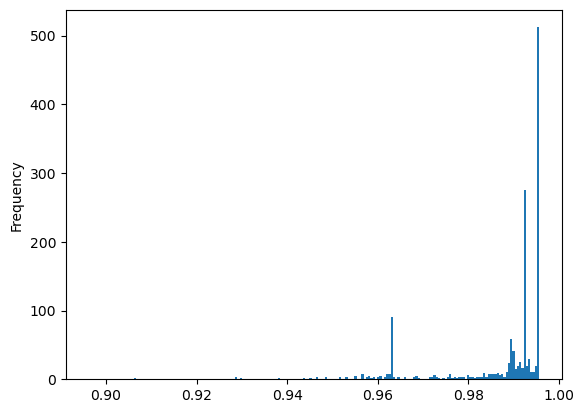

In [12]:
nextclade_df.coverage.plot.hist(bins=200)

## Increasing coverage to >= 0.98 and Saving Selection.

In [13]:
sequences_ids_better_coverage = nextclade_df[nextclade_df.coverage>=0.98]['seqName'].values
metadata = metadata[metadata['fasta header name'].isin(sequences_ids_better_coverage)]

In [14]:
metadata.parent_lineage.value_counts()

parent_lineage
LP.8.1.1    729
LP.8.1      415
NB.1.8.1     34
Name: count, dtype: int64

## Save selected metadata and sequences

In [15]:
metadata.to_csv('metadata.csv', index=False)

filtered_sequences = [
    record for record in SeqIO.parse("output/nextclade.aligned.fasta", "fasta")
    if record.id in metadata['fasta header name'].values
]

with open("sequences.fasta", "w") as out_file:
    SeqIO.write(filtered_sequences, out_file, "fasta")

In [16]:
with open("sub_lineages_map.yml", "w") as f:
    yaml.dump(sub_lineages_map, f, default_flow_style=False)